<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Обучение языковой модели с помощью LSTM </b></h1>


## задание

В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возможные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

## импорт

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import datetime
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
from torch.nn.utils import clip_grad_norm_
import nltk

import re
from collections import Counter
from typing import List

import seaborn
seaborn.set_theme(palette='summer')

nltk.download('punkt')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

[nltk_data] Downloading package punkt to /home/ext-
[nltk_data]     yankin@ad.speechpro.com/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


'cuda'

## загрузка и осмотр датасета
- датасет imdb: отзывы о фильмах с сайта imdb.

In [2]:
dataset = load_dataset('imdb')
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [3]:
X_train_df = dataset['train']['text']
y_train_df = dataset['train']['label']
idx = 0
X_train_df[idx], y_train_df[idx]

('I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, e

## подготовка датасета

### Препроцессинг данных и создание словаря (1 балл)
- далее необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк.  
Что необходимо сделать:
- разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из библиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
- оставить только те предложения, в которых меньше ```word_threshold``` слов.
- посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
- создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [ ]:
sentences = []
max_word_threshold = 32
min_word_threshold = 2

def clean_html(text):
    return re.sub(r'<[^>]+>', ' ', text)

for text in tqdm(dataset['train']['text'], desc="Cleaning texts"):
    clean_text = clean_html(text)
    
    for sent in sent_tokenize(clean_text, language='english'):
        tokens = word_tokenize(sent.lower())
        if min_word_threshold < len(tokens) < max_word_threshold: 
            sentences.append(tokens)

print("Всего предложений:", len(sentences))

Cleaning texts:   0%|          | 0/25000 [00:00<?, ?it/s]

In [ ]:
words = Counter()
for sent_tokens in tqdm(sentences, desc="Counting words"):
    words.update(sent_tokens)

In [ ]:
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_size = 40000

# Добавим в словарь vocab_size самых встречающихся слов.
for word, count in tqdm(words.most_common(vocab_size)):
    vocab.add(word)

print("Всего слов в словаре:", len(vocab))

In [ ]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

### Подготовка датасета (1 балл)
- подготовим датасеты и даталоадеры;
- в классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).
- внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [ ]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [ ]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [word2ind.get(word, self.unk_id) for word in self.data[idx]] 
        tokenized_sentence += [self.eos_id]

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [ ]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [ ]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## обучение и архитектура модели


### вспомогательные функции

#### evaluate (1 балл)
- заполните функцию ```evaluate```

In [ ]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

#### Train loop (1 балл)
- напишите функцию для обучения модели.

In [ ]:
def train_model(model, optimizer, criterion, train_dataloader, val_dataloader, num_epoch):
    model.to(device)
    
    losses = []
    perplexities = []

    for epoch in range(num_epoch):
        model.train()
        epoch_losses = []
        
        for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch}'):
            optimizer.zero_grad()
            
            x = batch['input_ids'].to(device)
            y = batch['target_ids'].to(device).flatten()
            
            # [batch_size * seq_len, vocab_size]
            logits = model(x).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, y)
            
            loss.backward()
            
            clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_losses.append(loss.item())
        
        avg_loss = sum(epoch_losses) / len(epoch_losses)
        losses.append(avg_loss)
        
        current_perplexity = evaluate(model, criterion, val_dataloader)
        perplexities.append(current_perplexity)

    return losses, perplexities

### архитектура

In [ ]:
class LanguageModel(nn.Module):
    def __init__(
        self, 
        vocab_size: int, 
        hidden_dim: int, 
        word2ind: dict,
        rnn_type: str = 'lstm', 
        num_layers: int = 1,
        num_linear_layers: int = 1,
        activation_type: str = 'Tanh',
        dropout_p: float = 0.2
    ):
        super().__init__()
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']
        
        self.embedding = nn.Embedding(
            vocab_size, 
            hidden_dim, 
            padding_idx=self.pad_id
        )

        rnn_class = getattr(nn, rnn_type.upper())
        if rnn_type.lower() not in ['rnn', 'lstm', 'gru']:
            raise ValueError('Use "LSTM", "GRU" or "RNN"')
        
        self.rnn = rnn_class(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_p if num_layers > 1 else 0
        )

        act_mapping = {
            'tanh': nn.Tanh,
            'relu': nn.ReLU,
            'sigmoid': nn.Sigmoid
        }
        
        act_type_lower = activation_type.lower()
        if act_type_lower not in act_mapping:
            raise ValueError('Use "Tanh", "ReLU" or "Sigmoid"')
        activation = act_mapping[act_type_lower]
        
        layers = []
        
        current_dim = hidden_dim
        for _ in range(num_linear_layers):
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(activation())
            layers.append(nn.Dropout(dropout_p))
            current_dim = hidden_dim
            
        self.hidden_layers = nn.Sequential(*layers)
        self.projection = nn.Linear(current_dim, vocab_size)

    def forward(self, input_ids) -> torch.Tensor:
        # input_ids: [batch_size, seq_len]

        x = self.embedding(input_ids) # [batch_size, seq_len, hidden_dim]
        
        # [batch_size, seq_len, hidden_dim * num_directions]
        rnn_out, _ = self.rnn(x)
        
        x = self.hidden_layers(rnn_out)
        
        # [batch_size, seq_len, vocab_size]
        return self.projection(x)

### эксперименты
- функции активации: `relu`, `tanh`;
- тип rnn ячейки: `rnn`, `lstm`, `gru`;
- размер слоя: `64`, `128`, `256`;
- количество слоёв: `1`, `2`.

In [ ]:
activation_types = ['ReLU', 'Tanh', 'Sigmoid']
rnn_types = ['lstm', 'gru', 'rnn']
layers_configs = [1, 2]
hidden_dims = [32, 64]

In [ ]:
agg_results = {}
num_epoch = 5
log_file = "training_log.txt"

for r_type in rnn_types:
    for a_type in activation_types:
        for n_layer in layers_configs:
            for h_dim in hidden_dims:
                exp_name = f"{r_type}_L{n_layer}_H{h_dim}_{a_type}"
                print(f"\nМодель: {exp_name}")
                
                status_msg = f"{datetime.datetime.now()}: Запуск {exp_name}"
                with open(log_file, "a") as log:
                    log.write(status_msg + "\n")

                model = LanguageModel(
                    vocab_size=len(vocab),
                    hidden_dim=h_dim,
                    word2ind=word2ind,
                    rnn_type=r_type,
                    num_layers=n_layer,
                    activation_type=a_type
                )

                optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
                criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])

                train_losses, valid_perplexities = train_model(
                    model, optimizer, criterion, 
                    train_dataloader, eval_dataloader, num_epoch
                )

                agg_results[exp_name] = valid_perplexities
                
                with open(log_file, "a") as log:
                    last_ppl = valid_perplexities[-1]
                    log.write(f"Завершено: {exp_name} | Final PPL: {last_ppl:.2f}\n")
                
                with open('agg_results_backup.pkl', 'wb') as f:
                    pickle.dump(agg_results, f)
                    
                torch.cuda.empty_cache()

### агрегация результатов

In [21]:
colors = ['red', 'blue', 'green', 'orange']

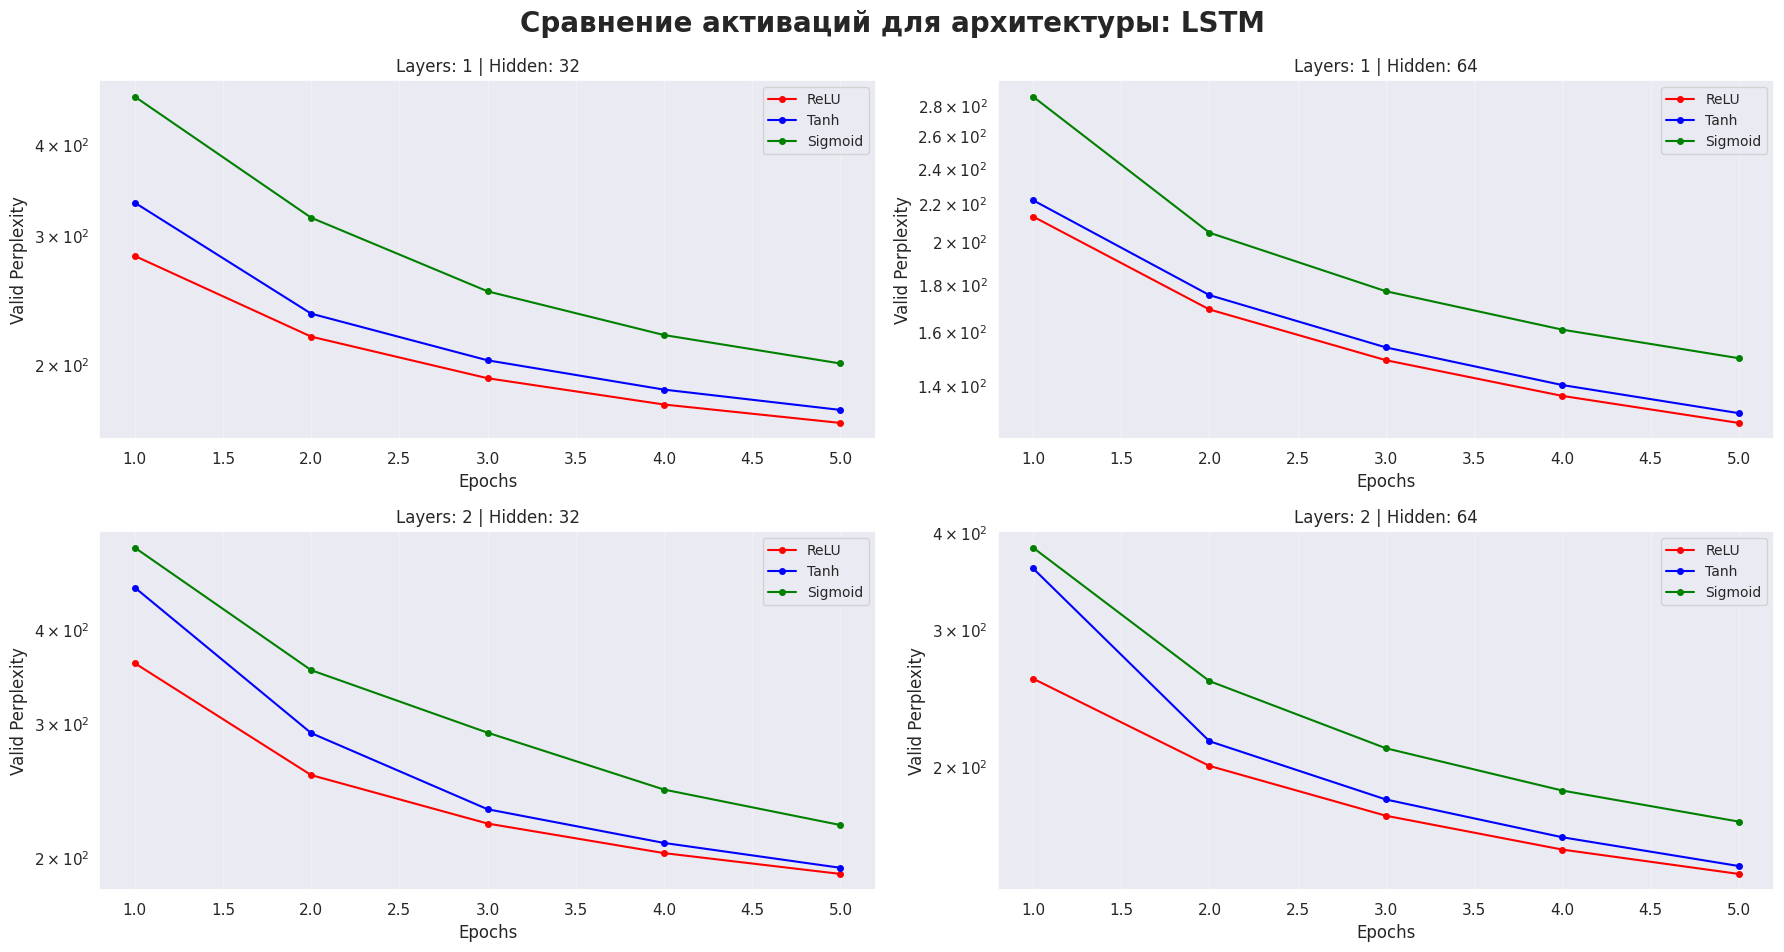

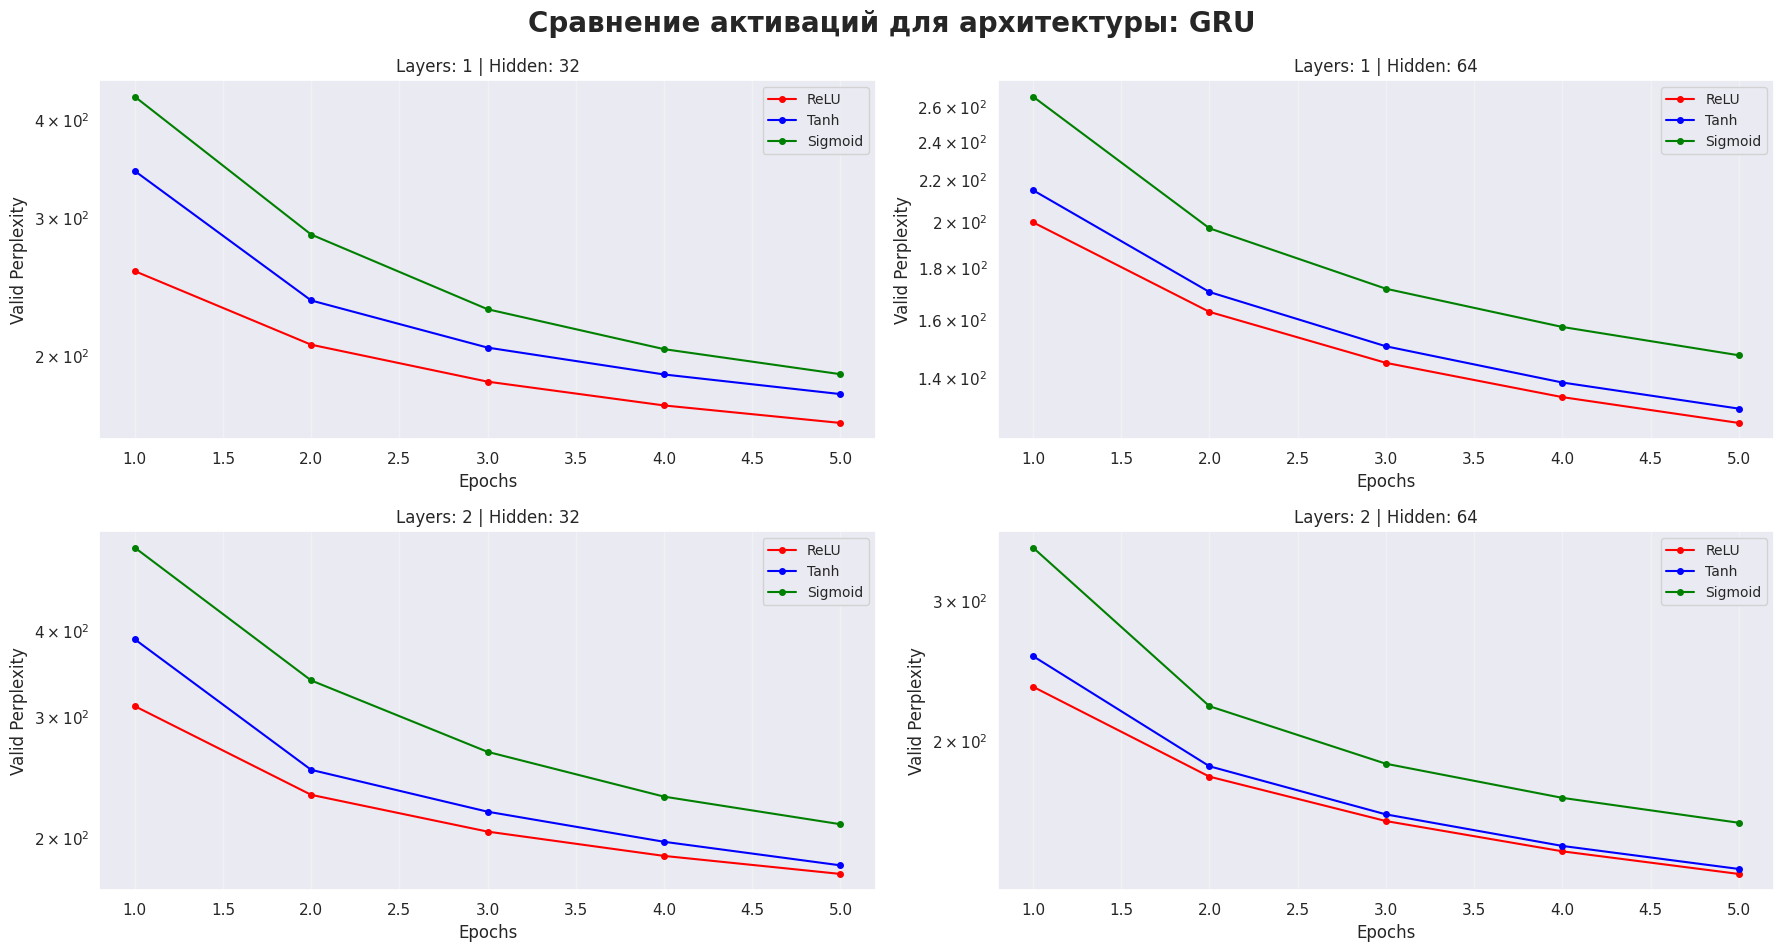

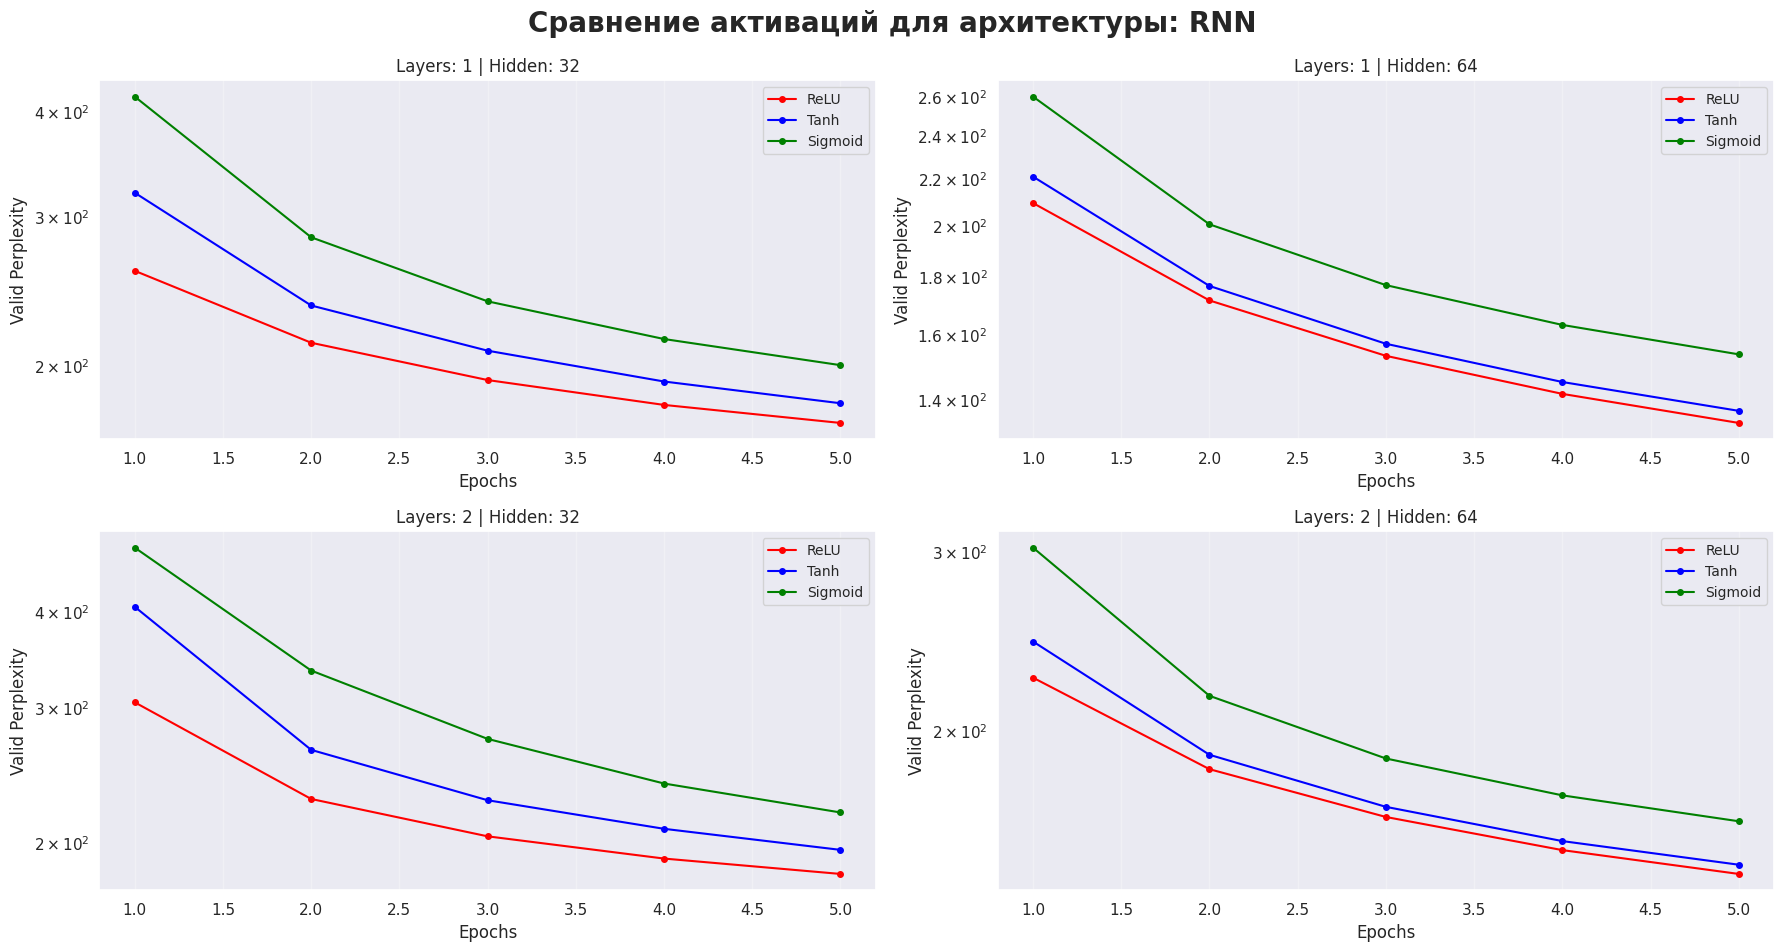

In [22]:
for curr_rnn in rnn_types:
    fig, axes = plt.subplots(len(layers_configs), len(hidden_dims), 
                             figsize=(18, 10), sharey=False)
    
    if len(layers_configs) == 1: axes = [axes]
    if len(hidden_dims) == 1: axes = [[a] for a in axes]

    for i, n_layer in enumerate(layers_configs):
        for j, h_dim in enumerate(hidden_dims):
            ax = axes[i][j]

            for a_type, color in zip(activation_types, colors):
                key = f"{curr_rnn}_L{n_layer}_H{h_dim}_{a_type}"

                if key in agg_results:
                    data = agg_results[key]
                    ax.plot(range(1, len(data) + 1), data, 
                            label=a_type, color=color, marker='o', markersize=4)

            ax.set_title(f"Layers: {n_layer} | Hidden: {h_dim}")
            ax.set_xlabel("Epochs")
            ax.set_ylabel("Valid Perplexity")
            
            ax.set_yscale('log') 
            ax.legend(fontsize='small')
            ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle(f'Сравнение активаций для архитектуры: {curr_rnn.upper()}', fontsize=20, weight='bold')
    plt.show()

In [26]:
results_list = []
for exp_name, perplexities in agg_results.items():
    best_ppl = min(perplexities)
    last_ppl = perplexities[-1]
    
    parts = exp_name.split('_')
    results_list.append({
        'Model': parts[0],
        'Layers': parts[1],
        'Hidden': parts[2],
        'Activation': parts[3],
        'Best Perplexity': round(best_ppl, 2),
        'Last Perplexity': round(last_ppl, 2)
    })

df_results = pd.DataFrame(results_list)
df_results = df_results.sort_values(by='Best Perplexity')
df_results

,Model,Layers,Hidden,Activation,Best Perplexity,Last Perplexity
13,gru,L1,H64,ReLU,126.48,126.48
1,lstm,L1,H64,ReLU,127.87,127.87
17,gru,L1,H64,Tanh,130.68,130.68
5,lstm,L1,H64,Tanh,131.01,131.01
25,rnn,L1,H64,ReLU,133.70,133.70
15,gru,L2,H64,ReLU,135.89,135.89
29,rnn,L1,H64,Tanh,137.05,137.05
19,gru,L2,H64,Tanh,137.86,137.86
27,rnn,L2,H64,ReLU,144.80,144.80
3,lstm,L2,H64,ReLU,145.54,145.54


## выводы

* лучшие результаты показали gru (126,48) и lstm (127,87), обычная rnn заметно отстает;
* увеличение скрытого слоя с h32 до h64 — самый эффективный способ снижения перплексии (прирост качества на ~40 единиц);
* однослойные модели (l1) парадоксально лучше двухслойных (l2). вероятно, больше слоёв - быстрее переобучение;
* выбор активации: relu — фаворит по точности; sigmoid — худший вариант из-за затухания градиентов.

идеи по улучшению:
* протестировать ширину слоя h128 и выше;
* внедрить dropout для стабилизации многослойных (l2) конфигураций;
* использовать предобученные эмбеддинги (word2vec/fasttext);
* добавить learning rate scheduler для более тонкой настройки весов на поздних эпохах.